In [7]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("../../dataset/feature_store/df_model.csv")

TARGET = "churn_label"

# ── Extract Co_Ref from year_key (year_key = Co_Ref + "_" + Renewal_Year) ──
df["Co_Ref"] = df["year_key"].str.rsplit("_", n=1).str[0]

# ── Identifier columns — for explainability, never enter the model ──────────
ID_COLS = ["Co_Ref", "year_key", "Renewal_Year"]

X = df.drop(columns=[TARGET] + [c for c in ID_COLS if c in df.columns])
y = df[TARGET]
df_ids = df[ID_COLS].copy()

print(f"Shape        : {df.shape}")
print(f"Churn rate   : {y.mean():.4f}")
print(f"Features     : {X.shape[1]}")
print(f"Identifiers  : {ID_COLS}")

Shape        : (112081, 81)
Churn rate   : 0.1071
Features     : 77
Identifiers  : ['Co_Ref', 'year_key', 'Renewal_Year']


In [9]:
# ============================================================
# STEP 2 — STRATIFIED TRAIN/TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain shape  : {X_train.shape}")
print(f"Test shape   : {X_test.shape}")
print(f"Train churn  : {y_train.mean():.4f}")
print(f"Test churn   : {y_test.mean():.4f}")


Train shape  : (89664, 77)
Test shape   : (22417, 77)
Train churn  : 0.1071
Test churn   : 0.1071


In [10]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\nCategorical columns: {cat_cols}")

encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # Handle unseen values in test
    X_test[col] = X_test[col].astype(str)
    X_test[col] = X_test[col].map(lambda s: s if s in le.classes_ else "UNKNOWN")
    le.classes_ = np.append(le.classes_, "UNKNOWN")
    X_test[col] = le.transform(X_test[col])

    encoders[col] = le

print(f"Shape after encoding: {X_train.shape}")


Categorical columns: ['Connection_Group', 'Proforma_Account_Stage', 'Proforma_Membership_Status', 'Band', 'Last_Band', 'Audit_Status_Group', 'Tenure_Group', 'Discount_Amount', 'Anchor_Group']
Shape after encoding: (89664, 77)


In [11]:
print("\n>>> Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("RF done")



>>> Training Random Forest...


RF done


In [12]:
print("\n>>> Training XGBoost...")

# scale_pos_weight = majority / minority
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale:.2f}")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    scale_pos_weight=scale,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("XGBoost training done ")


>>> Training XGBoost...
scale_pos_weight : 8.34
XGBoost training done 


In [13]:
print("\n>>> Aggregating ranks...")

rf_rank  = rf_importance.rank(ascending=False,  method="min")
xgb_rank = xgb_importance.rank(ascending=False, method="min")

combined = pd.DataFrame({
    "rf_importance"  : rf_importance,
    "xgb_importance" : xgb_importance,
    "rf_rank"        : rf_rank,
    "xgb_rank"       : xgb_rank,
})

combined["avg_rank"] = (combined["rf_rank"] + combined["xgb_rank"]) / 2
combined = combined.sort_values("avg_rank")

print("\nTop 20 by Combined Rank:")
print(combined.head(20).to_string())


>>> Aggregating ranks...

Top 20 by Combined Rank:
                            rf_importance  xgb_importance  rf_rank  xgb_rank  avg_rank
payment_timeframe_missing        0.346878             1.0      1.0       1.0       1.0
Total_Renewal_Score_New          0.151810             0.0      2.0       2.0       2.0
payment_unknown                  0.100711             0.0      3.0       2.0       2.5
Payment_Timeframe                0.077033             0.0      4.0       2.0       3.0
Sustainability_Score             0.050454             0.0      5.0       2.0       3.5
payment_is_bacs                  0.036934             0.0      6.0       2.0       4.0
Auto_Renewal_Score               0.032432             0.0      7.0       2.0       4.5
Tenure_Scores                    0.029986             0.0      8.0       2.0       5.0
Current_World_Pay_Token          0.025935             0.0      9.0       2.0       5.5
payment_is_card                  0.021220             0.0     10.0       2.0  

In [14]:
TOP_N = 52   # adjust if needed

tree_selected = combined.head(TOP_N).index.tolist()

print(f"\nTree selected features : {len(tree_selected)}")
print(tree_selected)


Tree selected features : 52
['payment_timeframe_missing', 'Total_Renewal_Score_New', 'payment_unknown', 'Payment_Timeframe', 'Sustainability_Score', 'payment_is_bacs', 'Auto_Renewal_Score', 'Tenure_Scores', 'Current_World_Pay_Token', 'payment_is_card', 'Renewal_Score_At_Release', 'Proforma_Membership_Status', 'Discount_Amount', 'price_increase_pct', 'Gross', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Current_Anchorings', 'Last_Band', 'price_change', 'Anchoring_Score', 'Proforma_World_Pay_Token', 'Tenure_Years', '#_of_Connection', 'is_new_customer', 'Last_Connections', 'Tenure_Group', 'rc_desire_cancel_desired_to_cancel_true', 'crm_contractor_suggested_leave', 'Current_Auto_Renewal_Flag', 'crm_contractor_sentiment_score', 'Amount', 'PQQNet', 'had_rc_interaction', 'rc_Membership_Renewal_Decision', 'payment_is_worldpay', 'Band', 'had_em_interaction', 'Connection_Group', 'crm_agent_chase_count', 'crm_negative_customer_experience', 'Anchor_Group', 'crm_financial_hardship_mentioned', 

In [15]:
business_critical = [
    "Tenure_Years", "Band", "Last_Band", "Current_Auto_Renewal_Flag",
    "Gross", "Amount", "Total_Renewal_Score_New", "Renewal_Score_At_Release",
    "Anchoring_Score", "Sustainability_Score", "Auto_Renewal_Score",
    "#_of_Connection", "Connection_Group", "Anchor_Group",

    "rc_Membership_Renewal_Decision", "crm_contractor_suggested_leave",
    "crm_customer_complained", "crm_dissatisified_with_renewal_price",
    "crm_financial_hardship_mentioned", "rc_desire_cancel_desired_to_cancel_true",
    "rc_churn_cat_cost___price___too_expensive_true",
    "rc_churn_cat_financial_struggles___business_problems_true",
    "had_cc_interaction", "had_em_interaction", "had_rc_interaction",
    "price_increase_pct", "price_change",

    "crm_agent_chase_count", "crm_membership_overdue",
    "crm_negative_customer_experience", "crm_contractor_sentiment_score"
]

In [16]:
missing = [f for f in business_critical if f not in tree_selected]

print("\nMissing business features:")
for f in missing:
    print(f)


Missing business features:
crm_dissatisified_with_renewal_price
rc_churn_cat_cost___price___too_expensive_true
rc_churn_cat_financial_struggles___business_problems_true
had_cc_interaction


In [17]:
final_features = list(dict.fromkeys(tree_selected + missing))

print("\nFinal feature count:", len(final_features))


Final feature count: 56


In [18]:
print("\n" + "=" * 60)
print("FINAL FEATURE SET")
print("=" * 60)
print(f"Tree selected            : {len(tree_selected)}")
print(f"Forced additions         : {len(missing)}")
print(f"Final total              : {len(final_features)}")
print(f"\nFinal features list:")
for i, f in enumerate(final_features, 1):
    print(f"  {i:>2}. {f}")


FINAL FEATURE SET
Tree selected            : 52
Forced additions         : 4
Final total              : 56

Final features list:
   1. payment_timeframe_missing
   2. Total_Renewal_Score_New
   3. payment_unknown
   4. Payment_Timeframe
   5. Sustainability_Score
   6. payment_is_bacs
   7. Auto_Renewal_Score
   8. Tenure_Scores
   9. Current_World_Pay_Token
  10. payment_is_card
  11. Renewal_Score_At_Release
  12. Proforma_Membership_Status
  13. Discount_Amount
  14. price_increase_pct
  15. Gross
  16. Proforma_Account_Stage
  17. Audit_Status_Group
  18. Current_Anchorings
  19. Last_Band
  20. price_change
  21. Anchoring_Score
  22. Proforma_World_Pay_Token
  23. Tenure_Years
  24. #_of_Connection
  25. is_new_customer
  26. Last_Connections
  27. Tenure_Group
  28. rc_desire_cancel_desired_to_cancel_true
  29. crm_contractor_suggested_leave
  30. Current_Auto_Renewal_Flag
  31. crm_contractor_sentiment_score
  32. Amount
  33. PQQNet
  34. had_rc_interaction
  35. rc_Membershi

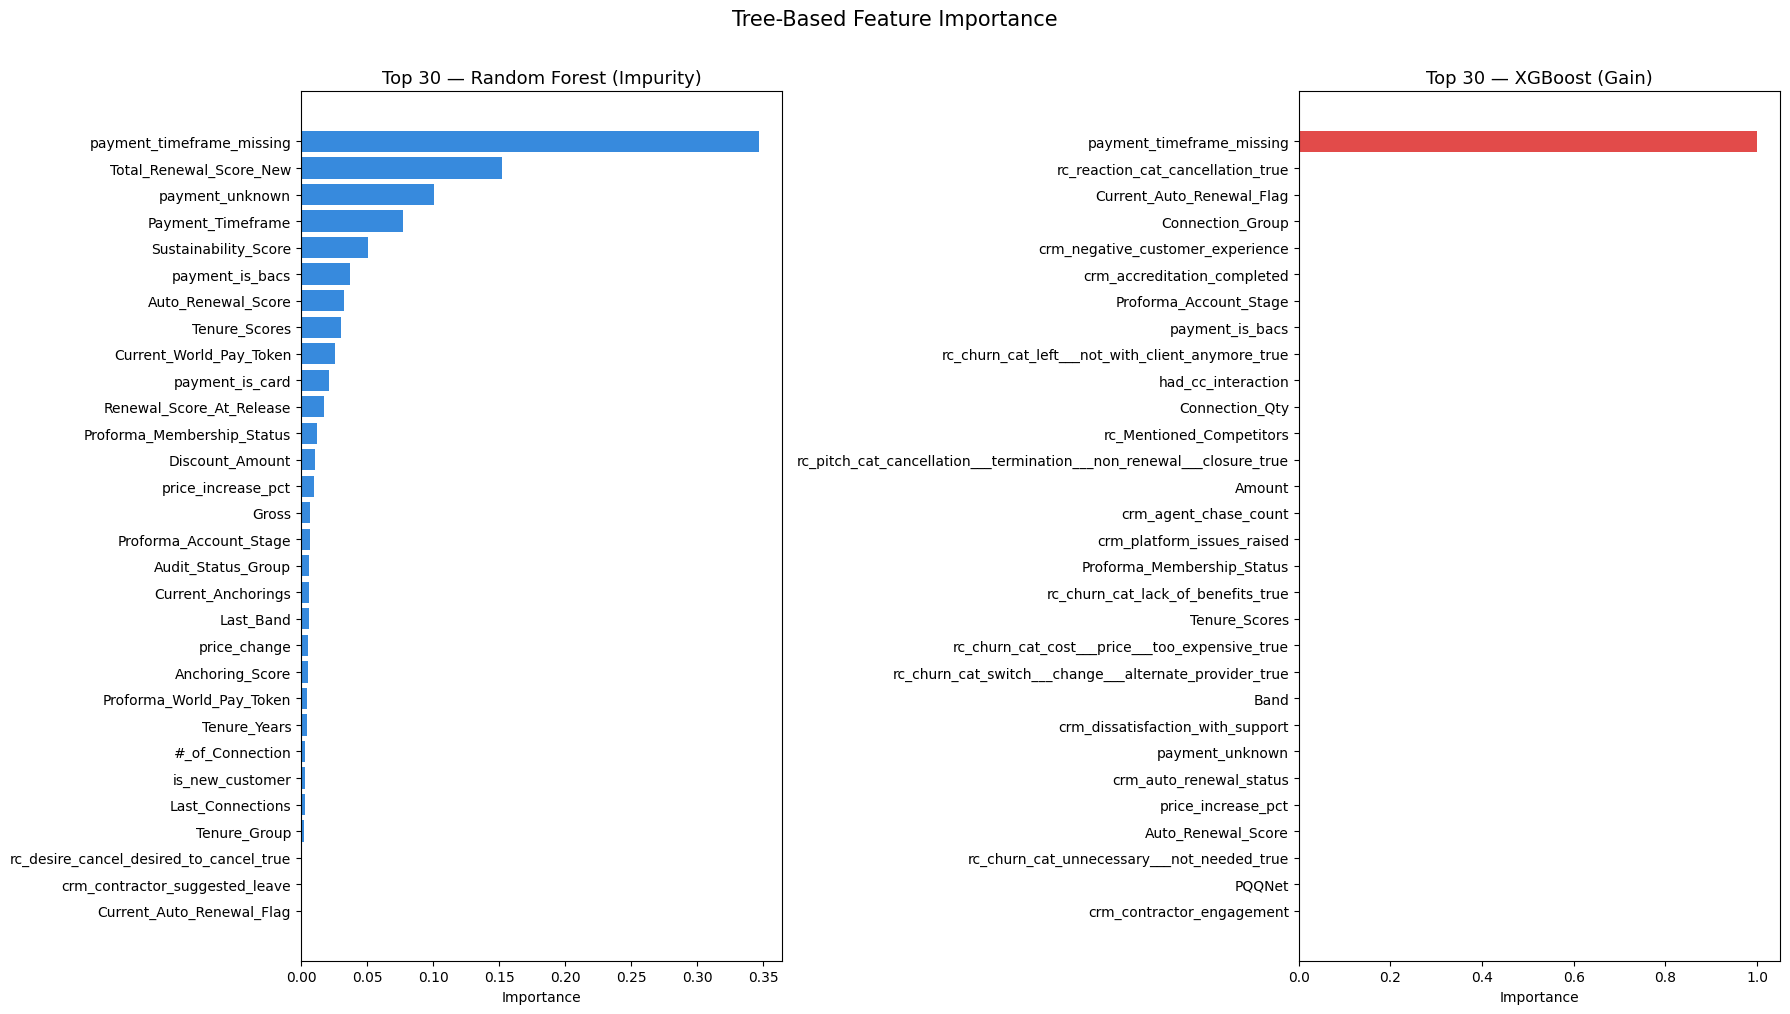

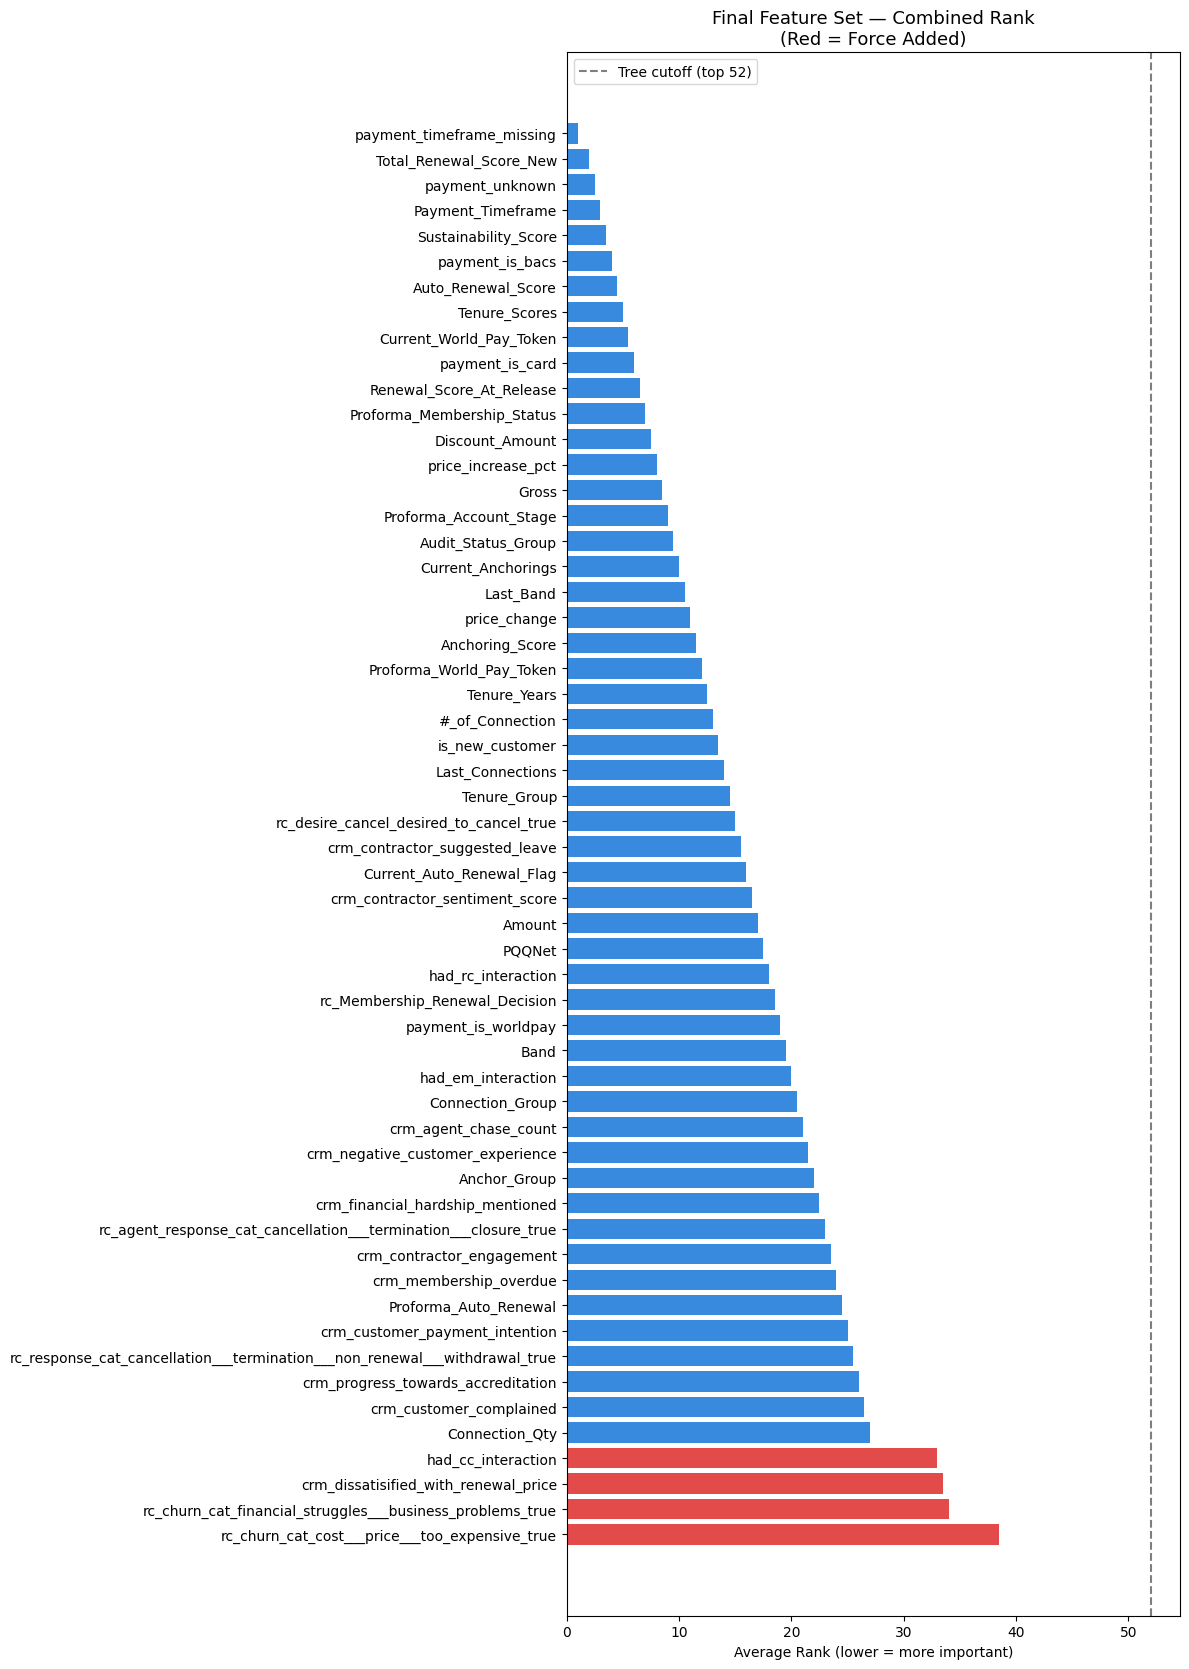


Done! Plots saved.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# RF Top 30
top30_rf = rf_importance.head(30)
axes[0].barh(top30_rf.index[::-1], top30_rf.values[::-1], color="#378ADD")
axes[0].set_title("Top 30 — Random Forest (Impurity)", fontsize=13)
axes[0].set_xlabel("Importance")

# XGBoost Top 30
top30_xgb = xgb_importance.head(30)
axes[1].barh(top30_xgb.index[::-1], top30_xgb.values[::-1], color="#E24B4A")
axes[1].set_title("Top 30 — XGBoost (Gain)", fontsize=13)
axes[1].set_xlabel("Importance")

plt.suptitle("Tree-Based Feature Importance", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Combined rank plot — final features only
final_rank_df = combined.loc[
    [f for f in final_features if f in combined.index]
].sort_values("avg_rank")

plt.figure(figsize=(12, max(6, len(final_rank_df) * 0.3)))
colors = ["#E24B4A" if f in missing else "#378ADD"
          for f in final_rank_df.index]
plt.barh(
    final_rank_df.index[::-1],
    final_rank_df["avg_rank"].values[::-1],
    color=colors[::-1]
)
plt.axvline(x=TOP_N, color="black", linestyle="--", alpha=0.5,
            label=f"Tree cutoff (top {TOP_N})")
plt.title("Final Feature Set — Combined Rank\n(Red = Force Added)", fontsize=13)
plt.xlabel("Average Rank (lower = more important)")
plt.legend()
plt.tight_layout()
plt.savefig("final_feature_set.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone! Plots saved.")

In [ ]:
# Combine features + target
# Combine features + identifiers + target
df_final = df[ID_COLS + final_features + [TARGET]]

print("\nFinal dataset shape:", df_final.shape)
print(f"Columns: {ID_COLS} + {len(final_features)} features + label")

# Save to CSV
output_path = "final_pre-renewal_churn_dataset.csv"
df_final.to_csv(output_path, index=False)

print(f"\nDataset saved successfully at: {}")


Final dataset shape: (112081, 60)
Columns: ['Co_Ref', 'year_key', 'Renewal_Year'] + 56 features + label

Dataset saved successfully at: final_pre-renewal_churn_dataset.csv
